In [1]:
##  Impprt Libraries
## In this section we import the required Python libraries for data manipulation, analysis and visualisation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_style("whitegrid")

In [2]:
df= pd.read_excel(
    "mikrozensus-arbeitsmarkt2023.xlsx", # Loading the Excel file.
    sheet_name="12211-01",
    header=[2,3]
)
df.head(8)

Geschlecht\nAlter (von ... bis unter ... Jahren)        Bevölkerung  \
                                Unnamed: 0_level_1 Unnamed: 1_level_1   
0                                              NaN           in 1 000   
1                                        Insgesamt                NaN   
2                                        Insgesamt              82472   
3                                        unter 15               11713   
4                                          15 - 16                787   
5                                          16 - 17                779   
6                                          17 - 18                772   
7                                          18 - 19                783   

  Erwerbspersonen                           Nichterwerbs-personen  
         zusammen Erwerbstätige Erwerbslose    Unnamed: 5_level_1  
0             NaN           NaN         NaN                   NaN  
1             NaN           NaN         NaN                   NaN  
2           43869         42527        1341               38603.0  
3               x             x           x               11713.0  
4              38            34           /                 749.0  
5             118           106          12                 660.0  
6             225           206          19                 547.0  
7             351           322          29                 432.0

In [3]:
df.columns

MultiIndex([('Geschlecht\nAlter (von ... bis unter ... Jahren)', ...),
            (                                     'Bevölkerung', ...),
            (                                 'Erwerbspersonen', ...),
            (                                 'Erwerbspersonen', ...),
            (                                 'Erwerbspersonen', ...),
            (                           'Nichterwerbs-personen', ...)],
           )

In [ ]:
## Data Cleaning

In [4]:
df.columns = ['_'.join(col).strip() # Flatten multi-level columns headers 
              for col in df.columns.values]
df.head() 

,Geschlecht\nAlter (von ... bis unter ... Jahren)_Unnamed: 0_level_1,Bevölkerung_Unnamed: 1_level_1,Erwerbspersonen_zusammen,Erwerbspersonen_Erwerbstätige,Erwerbspersonen_Erwerbslose,Nichterwerbs-personen_Unnamed: 5_level_1
0,NaN,in 1 000,NaN,NaN,NaN,NaN
1,Insgesamt,NaN,NaN,NaN,NaN,NaN
2,Insgesamt,82472,43869,42527,1341,38603.0
3,unter 15,11713,x,x,x,11713.0
4,15 - 16,787,38,34,/,749.0


In [5]:
df.columns

Index(['Geschlecht\nAlter (von ... bis unter ... Jahren)_Unnamed: 0_level_1',
       'Bevölkerung_Unnamed: 1_level_1', 'Erwerbspersonen_zusammen',
       'Erwerbspersonen_Erwerbstätige', 'Erwerbspersonen_Erwerbslose',
       'Nichterwerbs-personen_Unnamed: 5_level_1'],
      dtype='object')

In [6]:
df.columns=[        # clean columns names 
    "age_gender",
    "population_1000",
    "labour_force_total_1000",
    "employed_1000",
    "unemployed_1000",
    "not_in_labor_force_1000"
]

In [7]:
df.head()

,age_gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
0,NaN,in 1 000,NaN,NaN,NaN,NaN
1,Insgesamt,NaN,NaN,NaN,NaN,NaN
2,Insgesamt,82472,43869,42527,1341,38603.0
3,unter 15,11713,x,x,x,11713.0
4,15 - 16,787,38,34,/,749.0


In [8]:
df= df.iloc[2:].reset_index(drop=True) # remove nondata rows
df.head()

,age_gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
0,Insgesamt,82472,43869,42527,1341,38603.0
1,unter 15,11713,x,x,x,11713.0
2,15 - 16,787,38,34,/,749.0
3,16 - 17,779,118,106,12,660.0
4,17 - 18,772,225,206,19,547.0


In [9]:
df= df.replace(["x", "/"], pd.NA) # replace nonNumeric symbols

C:\Users\yaras\AppData\Local\Temp\ipykernel_171356\463111681.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df= df.replace(["x", "/"], pd.NA) # replace nonNumeric symbols


In [10]:
numeric_cols= df.columns[1:]  # convert columns to numeric
df[numeric_cols]= df[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [11]:
df.head()

,age_gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
0,Insgesamt,82472.0,43869.0,42527.0,1341.0,38603.0
1,unter 15,11713.0,NaN,NaN,NaN,11713.0
2,15 - 16,787.0,38.0,34.0,NaN,749.0
3,16 - 17,779.0,118.0,106.0,12.0,660.0
4,17 - 18,772.0,225.0,206.0,19.0,547.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_gender               310 non-null    object 
 1   population_1000          306 non-null    float64
 2   labour_force_total_1000  277 non-null    float64
 3   employed_1000            277 non-null    float64
 4   unemployed_1000          209 non-null    float64
 5   not_in_labor_force_1000  306 non-null    float64
dtypes: float64(5), object(1)
memory usage: 14.7+ KB


In [13]:
# assign gender based on section headers
df["gender"]= df["age_gender"].where( 
    df["age_gender"].isin(["Männlich", "Weiblich"])
)
df["gender"]= df["gender"].ffill() 

In [14]:
df= df[~df["age_gender"].isin(["Männlich", "Weiblich"])] # remove gender header rows

In [15]:
df["age_group"]= df["age_gender"] # creat clean age column

In [16]:
summary_values = [
    "Insgesamt",
    "15 und älter",
    "15-65",
    "20-65",
    "20-75",
    "25-65",
    "25-75",
    "55-65",
    "55-75"
]

df = df[~df["age_group"].isin(summary_values)] # remove summary rows

In [17]:
df.head()

,age_gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000,gender,age_group
0,Insgesamt,82472.0,43869.0,42527.0,1341.0,38603.0,NaN,Insgesamt
1,unter 15,11713.0,NaN,NaN,NaN,11713.0,NaN,unter 15
2,15 - 16,787.0,38.0,34.0,NaN,749.0,NaN,15 - 16
3,16 - 17,779.0,118.0,106.0,12.0,660.0,NaN,16 - 17
4,17 - 18,772.0,225.0,206.0,19.0,547.0,NaN,17 - 18


In [18]:
df["gender"].value_counts()

gender
Weiblich    104
Männlich    102
Name: count, dtype: int64

In [19]:
df= df.drop(columns=["age_gender"]) # remove the redundant column

In [20]:
df= df[  # reorder columns
    [
        "gender",
        "age_group",
        "population_1000",
        "labour_force_total_1000",
        "employed_1000",
        "unemployed_1000",
        "not_in_labor_force_1000"
    ]
]

In [ ]:
## Final Data Quality Check

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   206 non-null    object 
 1   age_group                308 non-null    object 
 2   population_1000          306 non-null    float64
 3   labour_force_total_1000  277 non-null    float64
 4   employed_1000            277 non-null    float64
 5   unemployed_1000          209 non-null    float64
 6   not_in_labor_force_1000  306 non-null    float64
dtypes: float64(5), object(2)
memory usage: 19.2+ KB


In [22]:
df.describe()

,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
count,306.000000,277.000000,277.000000,209.000000,306.000000
mean,4329.718954,3198.826715,3104.476534,124.818182,1433.856209
std,11442.056080,8268.166263,8022.785532,277.017209,3974.896965
min,73.000000,6.000000,6.000000,6.000000,32.000000
25%,482.250000,200.000000,194.000000,13.000000,106.250000
50%,651.500000,495.000000,482.000000,20.000000,263.000000
75%,1364.000000,994.000000,962.000000,61.000000,635.500000
max,82472.000000,43869.000000,42527.000000,1341.000000,38603.000000


In [23]:
df.head()

,gender,age_group,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
0,NaN,Insgesamt,82472.0,43869.0,42527.0,1341.0,38603.0
1,NaN,unter 15,11713.0,NaN,NaN,NaN,11713.0
2,NaN,15 - 16,787.0,38.0,34.0,NaN,749.0
3,NaN,16 - 17,779.0,118.0,106.0,12.0,660.0
4,NaN,17 - 18,772.0,225.0,206.0,19.0,547.0


In [ ]:
## Exploratory Data Analysis (EDA)

In [24]:
df.shape

(308, 7)

In [25]:
df["age_group"].value_counts()

age_group
unter 15             3
18 - 19              3
15 - 16              3
16 - 17              3
17 - 18              3
                    ..
55 - 65              3
Zusammen             2
 Insgesamt           1
__________           1
Ende der Tabelle.    1
Name: count, Length: 105, dtype: int64

In [26]:
df["gender"].value_counts()

gender
Weiblich    104
Männlich    102
Name: count, dtype: int64

In [27]:
df.describe()

,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
count,306.000000,277.000000,277.000000,209.000000,306.000000
mean,4329.718954,3198.826715,3104.476534,124.818182,1433.856209
std,11442.056080,8268.166263,8022.785532,277.017209,3974.896965
min,73.000000,6.000000,6.000000,6.000000,32.000000
25%,482.250000,200.000000,194.000000,13.000000,106.250000
50%,651.500000,495.000000,482.000000,20.000000,263.000000
75%,1364.000000,994.000000,962.000000,61.000000,635.500000
max,82472.000000,43869.000000,42527.000000,1341.000000,38603.000000


In [28]:
df.dtypes

gender                      object
age_group                   object
population_1000            float64
labour_force_total_1000    float64
employed_1000              float64
unemployed_1000            float64
not_in_labor_force_1000    float64
dtype: object

In [29]:
df.isna().sum() # check missing value in each column

gender                     102
age_group                    0
population_1000              2
labour_force_total_1000     31
employed_1000               31
unemployed_1000             99
not_in_labor_force_1000      2
dtype: int64

In [30]:
(df.isna().sum() / len(df)) * 100 # missing values percentage

gender                     33.116883
age_group                   0.000000
population_1000             0.649351
labour_force_total_1000    10.064935
employed_1000              10.064935
unemployed_1000            32.142857
not_in_labor_force_1000     0.649351
dtype: float64

In [31]:
df["gender"]= df["gender"].ffill().bfill() # fix gender assignment
df["gender"].isna().sum() # verfiy fix

np.int64(0)

In [32]:
df = df.dropna(                # cleaner dataset
    subset=[
        "population_1000",
        "labour_force_total_1000",
        "employed_1000",
        "unemployed_1000"
    ],
    how="all"
)

In [33]:
df.shape

(306, 7)

In [34]:
df.duplicated().sum() # Check Duplicates 

np.int64(0)

In [36]:
df.head()

,gender,age_group,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
0,Männlich,Insgesamt,82472.0,43869.0,42527.0,1341.0,38603.0
1,Männlich,unter 15,11713.0,NaN,NaN,NaN,11713.0
2,Männlich,15 - 16,787.0,38.0,34.0,NaN,749.0
3,Männlich,16 - 17,779.0,118.0,106.0,12.0,660.0
4,Männlich,17 - 18,772.0,225.0,206.0,19.0,547.0


# Analysis by Age Group

To understand how labor market dynamics change across different age groups, the dataset is grouped by age and gender.

In [37]:
age_gender_summary = df.groupby(["age_group", "gender"])[
    [
        "population_1000",
        "labour_force_total_1000",
        "employed_1000",
        "unemployed_1000"
    ]
].sum()

age_gender_summary.head(10) 

population_1000  labour_force_total_1000  employed_1000  \
age_group  gender                                                              
 Insgesamt Männlich          82472.0                  43869.0        42527.0   
15 - 16    Männlich           1199.0                     59.0           53.0   
           Weiblich            374.0                     17.0           15.0   
15 - 20    Männlich           5942.0                   1870.0         1711.0   
           Weiblich           1896.0                    551.0          507.0   
15 - 65    Männlich          79683.0                  64609.0        62535.0   
           Weiblich          26172.0                  19867.0        19296.0   
15 - 75    Männlich          93496.0                  66870.0        64768.0   
           Weiblich          31122.0                  20470.0        19893.0   
16 - 17    Männlich           1182.0                    182.0          163.0   

                     unemployed_1000  
age_group  gender                     
 Insgesamt Männlich           1341.0  
15 - 16    Männlich              0.0  
           Weiblich              0.0  
15 - 20    Männlich            159.0  
           Weiblich             43.0  
15 - 65    Männlich           2075.0  
           Weiblich            571.0  
15 - 75    Männlich           2102.0  
           Weiblich            577.0  
16 - 17    Männlich             19.0

In [38]:
# restructure data for easier analysis and visualization
age_gender_summary= age_gender_summary.reset_index()

In [39]:
# Age_based Rates
age_gender_summary["employment_rate"] = (
    age_gender_summary["employed_1000"] /
    age_gender_summary["population_1000"]
)

age_gender_summary["unemployment_rate"] = (
    age_gender_summary["unemployed_1000"] /
    age_gender_summary["labour_force_total_1000"]
)

age_gender_summary["participation_rate"] = (
    age_gender_summary["labour_force_total_1000"] /
    age_gender_summary["population_1000"]
)

age_gender_summary

,age_group,gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,employment_rate,unemployment_rate,participation_rate
0,Insgesamt,Männlich,82472.0,43869.0,42527.0,1341.0,0.515654,0.030568,0.531926
1,15 - 16,Männlich,1199.0,59.0,53.0,0.0,0.044204,0.000000,0.049208
2,15 - 16,Weiblich,374.0,17.0,15.0,0.0,0.040107,0.000000,0.045455
3,15 - 20,Männlich,5942.0,1870.0,1711.0,159.0,0.287950,0.085027,0.314709
4,15 - 20,Weiblich,1896.0,551.0,507.0,43.0,0.267405,0.078040,0.290612
...,...,...,...,...,...,...,...,...,...
200,Ausgewählte Altersgruppen 15 un...,Weiblich,36041.0,20539.0,19962.0,578.0,0.553869,0.028142,0.569879
201,Zusammen,Männlich,40726.0,23329.0,22566.0,764.0,0.554093,0.032749,0.572828
202,Zusammen,Weiblich,41746.0,20539.0,19962.0,578.0,0.478178,0.028142,0.491999
203,unter 15,Männlich,17720.0,0.0,0.0,0.0,0.000000,NaN,0.000000


<Axes: xlabel='age_group'>

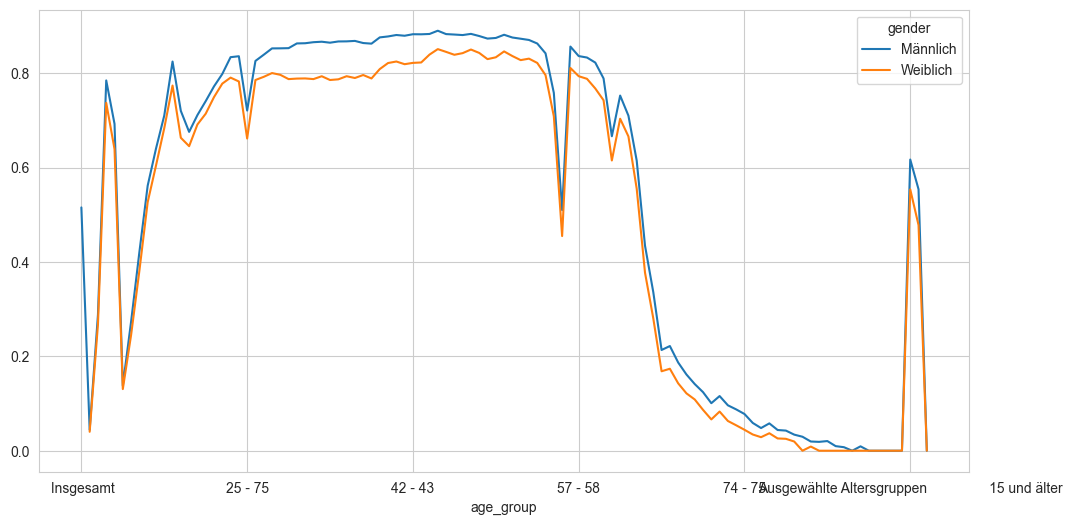

In [40]:
# visualize employment rates by age groups to identify trends over the life cycle.
pivot_emp = age_gender_summary.pivot(
    index="age_group",
    columns="gender",
    values="employment_rate"
)

pivot_emp.plot(kind="line", figsize=(12,6))

In [41]:
# remove aggregated age groups to ensure that only true age intervals are analysied

invalid_age_groups = [
    "Insgesamt",
    "15 und älter",
    "15-65",
    "20-65",
    "20-75",
    "25-65",
    "25-75",
    "55-65",
    "55-75"
]

df = df[~df["age_group"].isin(invalid_age_groups)] 

In [42]:
df["age_group"] = (
    df["age_group"]
    .str.replace("\n", " ", regex=True)
    .str.strip()
)

In [43]:
df = df[
    df["age_group"].str.contains(
        r"unter|und älter|\d+ ?- ?\d+",
        regex=True
    )
]

In [44]:
df["age_group"].unique()

array(['unter 15', '15 - 16', '16 - 17', '17 - 18', '18 - 19', '19 - 20',
       '15 - 20', '20 - 21', '21 - 22', '22 - 23', '23 - 24', '24 - 25',
       '20 - 25', '25 - 26', '26 - 27', '27 - 28', '28 - 29', '29 - 30',
       '25 - 30', '30 - 31', '31 - 32', '32 - 33', '33 - 34', '34 - 35',
       '30 - 35', '35 - 36', '36 - 37', '37 - 38', '38 - 39', '39 - 40',
       '35 - 40', '40 - 41', '41 - 42', '42 - 43', '43 - 44', '44 - 45',
       '40 - 45', '45 - 46', '46 - 47', '47 - 48', '48 - 49', '49 - 50',
       '45 - 50', '50 - 51', '51 - 52', '52 - 53', '53 - 54', '54 - 55',
       '50 - 55', '55 - 56', '56 - 57', '57 - 58', '58 - 59', '59 - 60',
       '55 - 60', '60 - 61', '61 - 62', '62 - 63', '63 - 64', '64 - 65',
       '60 - 65', '65 - 66', '66 - 67', '67 - 68', '68 - 69', '69 - 70',
       '65 - 70', '70 - 71', '71 - 72', '72 - 73', '73 - 74', '74 - 75',
       '70 - 75', '75 - 76', '76 - 77', '77 - 78', '78 - 79', '79 - 80',
       '75 - 80', '80 - 81', '81 - 82', '82 - 83',

In [45]:
# filter strict age intervales. aggregated ranges(e.g 15-65) are removed to ensure precise analysis.
def is_valid_age(x):
    x = x.strip()
    
    if x == "unter 15" or x == "90 und älter":
        return True
    
    if "-" in x:
        parts = x.split("-")
        try:
            start = int(parts[0])
            end = int(parts[1])
            return end - start == 1
        except:
            return False
    
    return False

df = df[df["age_group"].apply(is_valid_age)]

In [46]:
df["age_group"].unique()

array(['unter 15', '15 - 16', '16 - 17', '17 - 18', '18 - 19', '19 - 20',
       '20 - 21', '21 - 22', '22 - 23', '23 - 24', '24 - 25', '25 - 26',
       '26 - 27', '27 - 28', '28 - 29', '29 - 30', '30 - 31', '31 - 32',
       '32 - 33', '33 - 34', '34 - 35', '35 - 36', '36 - 37', '37 - 38',
       '38 - 39', '39 - 40', '40 - 41', '41 - 42', '42 - 43', '43 - 44',
       '44 - 45', '45 - 46', '46 - 47', '47 - 48', '48 - 49', '49 - 50',
       '50 - 51', '51 - 52', '52 - 53', '53 - 54', '54 - 55', '55 - 56',
       '56 - 57', '57 - 58', '58 - 59', '59 - 60', '60 - 61', '61 - 62',
       '62 - 63', '63 - 64', '64 - 65', '65 - 66', '66 - 67', '67 - 68',
       '68 - 69', '69 - 70', '70 - 71', '71 - 72', '72 - 73', '73 - 74',
       '74 - 75', '75 - 76', '76 - 77', '77 - 78', '78 - 79', '79 - 80',
       '80 - 81', '81 - 82', '82 - 83', '83 - 84', '84 - 85', '85 - 86',
       '86 - 87', '87 - 88', '88 - 89', '89 - 90', '90 und älter'],
      dtype=object)

In [48]:
# creat age ordering variable to ensure correct sorting of age groups

def extract_age_start(x):
    if x == "unter 15":
        return 0
    if x == "90 und älter":
        return 90
    return int(x.split("-")[0])

df["age_start"] = df["age_group"].apply(extract_age_start)

In [49]:
# sort dataset by age
df= df.sort_values(by="age_start")

In [50]:
df.head(20)

,gender,age_group,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000,age_start
1,Männlich,unter 15,11713.0,NaN,NaN,NaN,11713.0,0
104,Männlich,unter 15,6007.0,NaN,NaN,NaN,6007.0,0
207,Weiblich,unter 15,5705.0,NaN,NaN,NaN,5705.0,0
105,Männlich,15 - 16,412.0,21.0,19.0,NaN,391.0,15
208,Weiblich,15 - 16,374.0,17.0,15.0,NaN,358.0,15
2,Männlich,15 - 16,787.0,38.0,34.0,NaN,749.0,15
3,Männlich,16 - 17,779.0,118.0,106.0,12.0,660.0,16
106,Männlich,16 - 17,403.0,64.0,57.0,7.0,340.0,16
209,Weiblich,16 - 17,375.0,55.0,49.0,NaN,320.0,16
210,Weiblich,17 - 18,375.0,100.0,92.0,8.0,275.0,17


In [51]:
df.groupby(["age_group", "gender"]).size().sort_values(ascending=False) # aggregat duplicate observations

age_group     gender  
15 - 16       Männlich    2
16 - 17       Männlich    2
19 - 20       Männlich    2
17 - 18       Männlich    2
18 - 19       Männlich    2
                         ..
85 - 86       Weiblich    1
89 - 90       Weiblich    1
88 - 89       Weiblich    1
90 und älter  Weiblich    1
unter 15      Weiblich    1
Length: 154, dtype: int64

In [52]:
df=df.groupby(["age_group", "gender"], as_index=False).sum() # fix code

In [53]:
df.groupby(["age_group", "gender"]).size() # verfiy fix

age_group     gender  
15 - 16       Männlich    1
              Weiblich    1
16 - 17       Männlich    1
              Weiblich    1
17 - 18       Männlich    1
                         ..
89 - 90       Weiblich    1
90 und älter  Männlich    1
              Weiblich    1
unter 15      Männlich    1
              Weiblich    1
Length: 154, dtype: int64

In [54]:
df["age_start"] = df["age_group"].apply(extract_age_start)
df = df.sort_values(by="age_start")

In [55]:
df.head(20)

,age_group,gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000,age_start
153,unter 15,Weiblich,5705.0,0.0,0.0,0.0,5705.0,0
152,unter 15,Männlich,17720.0,0.0,0.0,0.0,17720.0,0
0,15 - 16,Männlich,1199.0,59.0,53.0,0.0,1140.0,15
1,15 - 16,Weiblich,374.0,17.0,15.0,0.0,358.0,15
2,16 - 17,Männlich,1182.0,182.0,163.0,19.0,1000.0,16
3,16 - 17,Weiblich,375.0,55.0,49.0,0.0,320.0,16
4,17 - 18,Männlich,1169.0,350.0,320.0,31.0,818.0,17
5,17 - 18,Weiblich,375.0,100.0,92.0,8.0,275.0,17
6,18 - 19,Männlich,1185.0,544.0,499.0,46.0,641.0,18
7,18 - 19,Weiblich,380.0,158.0,145.0,13.0,223.0,18


In [56]:
# final age and gender aggregation
age_gender_summary= df.copy()

In [57]:
# final rates calculation

age_gender_summary["employment_rate"] = (
    age_gender_summary["employed_1000"] /
    age_gender_summary["population_1000"]
)

age_gender_summary["unemployment_rate"] = (
    age_gender_summary["unemployed_1000"] /
    age_gender_summary["labour_force_total_1000"]
)

age_gender_summary["participation_rate"] = (
    age_gender_summary["labour_force_total_1000"] /
    age_gender_summary["population_1000"]
)

In [58]:
# prepare data for visualization

pivot_emp = age_gender_summary.pivot(
    index="age_group",
    columns="gender",
    values="employment_rate"
)

pivot_unemp = age_gender_summary.pivot(
    index="age_group",
    columns="gender",
    values="unemployment_rate"
)

pivot_part = age_gender_summary.pivot(
    index="age_group",
    columns="gender",
    values="participation_rate"
)

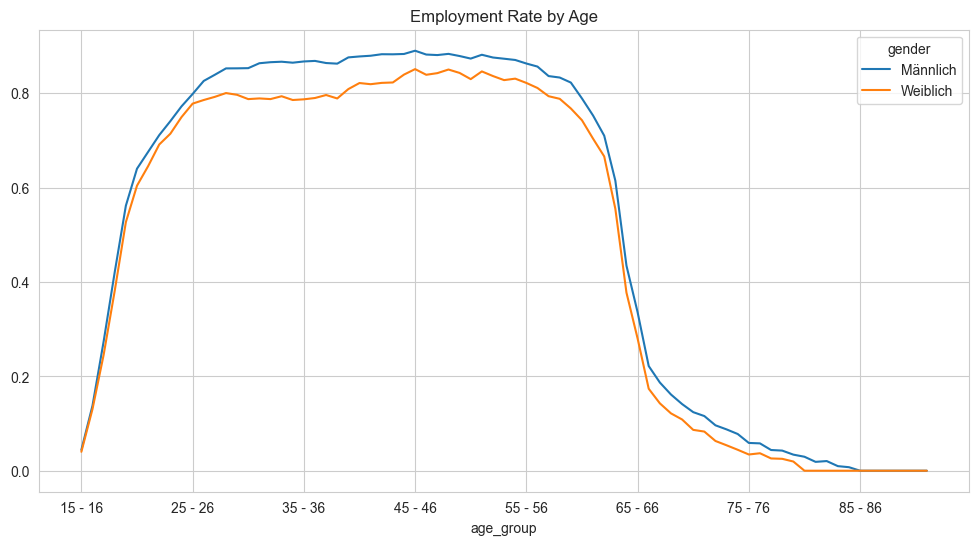

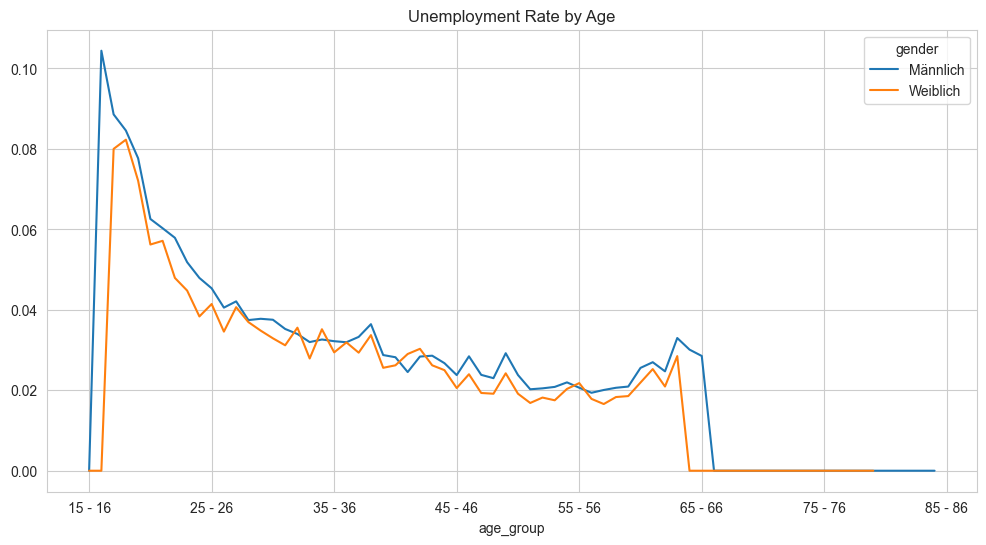

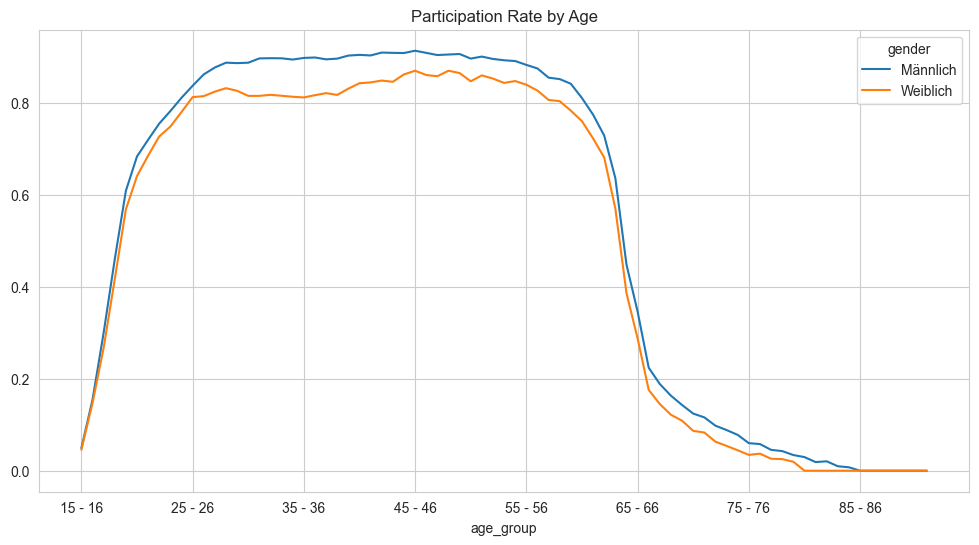

In [78]:
# visualization of labour market trends by age

pivot_emp.plot(kind="line", figsize=(12,6), title="Employment Rate by Age")
plt.savefig("images/employment_by_age.png")

pivot_unemp.plot(kind="line", figsize=(12,6), title="Unemployment Rate by Age")
plt.savefig("images/unemployment_by_age.png")

pivot_part.plot(kind="line", figsize=(12,6), title="Participation Rate by Age")
plt.savefig("images/participation_by_age.png")

### Employment Rate by Age

Employment rates for both genders begin to increase sharply from ages 15–16, reflecting entry into the labor market.

The rate continues to rise steadily and reaches its peak around the age group 45–46 for both genders.

After approximately age 55, employment rates begin to decline, indicating gradual exit from the workforce.

A notable gender-specific pattern appears for females: a temporary decline in employment occurs around the mid-30s (approximately 35–36), followed by recovery and continued growth until the peak. This suggests a potential mid-career interruption.

### Unemployment Rate by Age

Unemployment is highest at the youngest working age group (15–16), particularly among males.

This reflects initial entry into the labor market, where individuals face higher job-search friction.

After early ages, unemployment declines rapidly and stabilizes at relatively low levels throughout prime working ages.

There may be minor fluctuations in later ages, but these are less structurally significant compared to the early-age peak.

### Labor Force Participation by Age

Participation begins increasing at ages 15–16 as individuals enter the labor market.

Rates continue to rise into prime working ages and remain high until approximately age 55.

After this point, participation declines steadily as individuals transition into retirement.

Men maintain higher participation rates across most age groups.

Women exit the labor force earlier on average, particularly noticeable in older age groups.

### Gender Gap Across Age Groups

A consistent gender gap exists in both employment and participation rates, with males generally exhibiting higher values.

The gap becomes particularly noticeable in the mid-30s, where female employment shows a temporary decline before recovering.

This pattern may reflect life-cycle factors such as career interruptions.

After this period, the gap narrows slightly but remains present across most age groups.

# Labor Market Analysis by Gender

The dataset is aggregated by gender to compare key labor market indicators.
All calculations are based on the cleaned and validated dataset.

In [60]:
gender_summary = df.groupby("gender", as_index=False)[
    [
        "population_1000",
        "labour_force_total_1000",
        "employed_1000",
        "unemployed_1000",
        "not_in_labor_force_1000"
    ]
].sum()

gender_summary

,gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000
0,Männlich,123194.0,67163.0,65057.0,2080.0,56001.0
1,Weiblich,41746.0,20517.0,19944.0,563.0,21204.0


In [61]:
# gender based rates calculation

gender_rates = gender_summary.copy()

gender_rates["employment_rate"] = (
    gender_rates["employed_1000"] / gender_rates["population_1000"]
)

gender_rates["unemployment_rate"] = (
    gender_rates["unemployed_1000"] / gender_rates["labour_force_total_1000"]
)

gender_rates["participation_rate"] = (
    gender_rates["labour_force_total_1000"] / gender_rates["population_1000"]
)

gender_rates

,gender,population_1000,labour_force_total_1000,employed_1000,unemployed_1000,not_in_labor_force_1000,employment_rate,unemployment_rate,participation_rate
0,Männlich,123194.0,67163.0,65057.0,2080.0,56001.0,0.528086,0.030969,0.545181
1,Weiblich,41746.0,20517.0,19944.0,563.0,21204.0,0.477746,0.027441,0.491472


<Axes: xlabel='gender'>

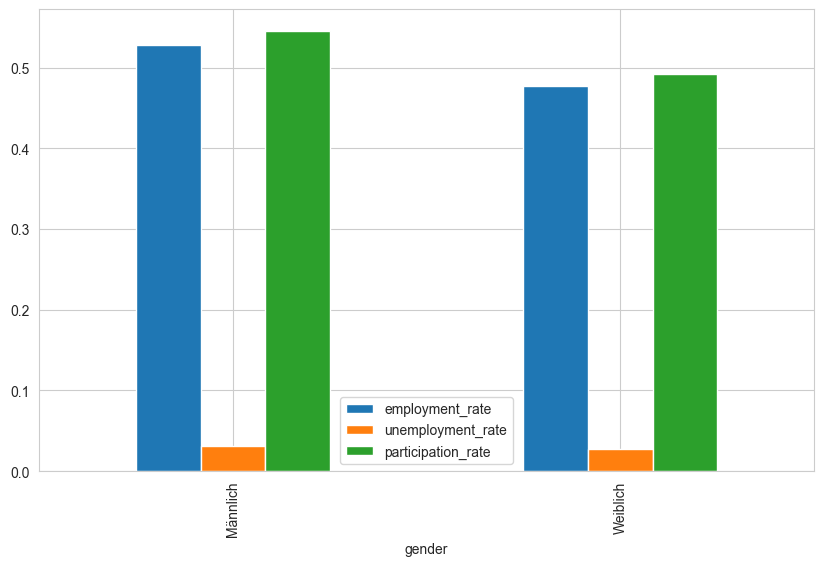

In [74]:
gender_rates[
    ["employment_rate", "unemployment_rate", "participation_rate"]
].plot(kind="bar", figsize=(10,6))


In [76]:
gender_rates[
    ["employment_rate", "unemployment_rate", "participation_rate"]
].plot(kind="bar", figsize=(10,6))

plt.tight_layout()
plt.savefig("images/gender_comparison.png")
plt.close()

### Gender-Based Labor Market Insights

After analyzing the cleaned dataset, several key patterns emerge:

- The **employment rate** is higher among males, indicating stronger overall integration into the workforce.

- The **labor force participation rate** is also higher for males, suggesting that a larger proportion of men are either employed or actively seeking employment.

- The **unemployment rate** is very similar between genders, with only minor differences. This indicates that once individuals participate in the labor market, both genders face comparable unemployment risks.

Overall, the primary difference between genders lies in participation rather than unemployment.

## Data Challenges and Cleaning Process

During the analysis, several data quality issues were identified and resolved:

- The dataset contained structural rows such as aggregated age groups (e.g., "15–65") and summary categories ("Insgesamt"), which were removed to ensure accurate analysis.

- Duplicate observations were present due to the structure of the original Excel file. These were resolved through aggregation to ensure one observation per age group and gender.

- Text inconsistencies (e.g., hidden spaces and line breaks) required normalization before filtering.

- Initial analysis results were re-evaluated after cleaning to ensure correctness and reliability.

This process highlights the importance of iterative data validation in real-world data analysis.